# Machine Learning Algorithms From Scratch

<a name="outline"></a>

## Outline

- [Intro](#intro): Context and Setup
  - [0.1](#q01): Introduction
  - [0.2](#q02): Setup
- [Task 1](#task-1): Regression
  - [1.1](#q11) Linear regression
  - [1.2](#q12) Ridge regression
  - [1.3](#q13) Lasso regression
- [Task 2](#task-2): Classification
  - [2.1](#q21) kNN classifier
  - [2.2](#q22) Random forest 
  - [2.3](#q23) Support vector machine (SVM) 
- [Task 3](#task-3): Mastery component 
  - [3.1](#q31) Logistic regression and bagging 
  - [3.2](#q32) Kernelised SVM classifier 

<a name="intro"></a>
## Introduction [^](#outline)

The following is a modified version of a coursework project that I produced for my MSc in 2022 for the module *Methods for Data Science*. It focused on implementing standard machine learning models such as: OLS, ridge and lasso regression alongside random forests, KNN and SVMs. Models were made using standard numpy and pandas packages without using the likes of sci-kit learn. What is presented here is a substantial modification to the original task to address several limitations:
1. For one, the project lacked any context for an individual outside of my cohort in 2022 without access to the assignment. Context has been added to explain this what is being done at each stage.
2. The original datasets were provided for us at the time and were given to us in a clean and preprocessed form. I wanted to work with something more realistic for this version of the project, plus, I find it much more interesting to fit the models to a new dataset to discover something new. In each section, the dataset used has been explained and context provided.
3. The original coursework was entirely focused on coding with mathematical derivations provided during lectures. Thorough mathematical derivations have been added at each stage to explain the underlying mathematics of each algorithm.
4. Errors were present. The original coursework, whilst it scored a top grade, I noticed several errors upon reviewing and did not want to present it publicly without amending them. The original file can be found as a previous version in the interest of transparency.
5. A separate model using sci-kit learn has been fitted at various stages for comparison purposes to see how accuracte the from-scratch derivations are.
6. Docstrings have been added to each function.
7. Some minor changes to aesthetics and rewording for clarity have been conducted.

#### Updates:

15th April 2026:
First upload of the modified file. All of Task 1 has been redone to a satisfactory standard. Tasks 2.1 and 2.2 are nearly complete. The rest remains unaltered.

<a name="setup"></a>
## Setup [^](#outline)

Here we load the necessary packages for the entire notebook.

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import random
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, recall_score, accuracy_score, precision_score, f1_score

# Create a seed for any random number generators to ensure reproducibility
seed = 123

<a name="task-1"></a>
# Task 1: Regression [^](#outline)


Our first task will be a regression task. For this task, we will look at a dataset containing various antropometric measurements of possums. The original source of the dataset can be found here:

*Lindenmayer, D. B., Viggers, K. L., Cunningham, R. B., and Donnelly, C. F. 1995. Morphological variation among columns of the mountain brushtail possum, Trichosurus caninus Ogilby (Phalangeridae: Marsupiala). Australian Journal of Zoology 43: 449-458*

Several of the measurements include things like: the population the possum belongs to, the site the measurements took place on, its head length, foot length, age, etc.

We will make it our goal to predict possum head length based on the remaining variables.

## 1.0 Data Cleaning

We begin by loading the dataset and taking a brief examination.

In [128]:
# Download latest version.
# NOTE: Change output_dir to any suitable directory on your device

path_possum = kagglehub.dataset_download("abrambeyer/openintro-possum", output_dir="D:\jupyter\data", force_download=True)
df = pd.read_csv(str(path_possum)+"\possum.csv")
df.head()

100%|██████████| 2.15k/2.15k [00:00<00:00, 118kB/s]

Extracting files...


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


We note several issues: the variable *case* is nothing more than a duplicate index column, we will remove this. The variables *Pop* and *sex* are categorical and will need to be one-hot encoded.

We'll now check for missing and duplicate values.

In [129]:
# Check for missing values
df.isnull().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

Looking at the output above, in a worst case scenario we will lose only 3 observations out of 104 by removing them so in this case that is how we will proceed.

In [130]:
df = df.dropna()
df.reset_index(drop=True, inplace=True)
df.drop_duplicates(inplace=True)
df.shape

(101, 14)

We also see that there are no duplicates in the dataset. We'll now one-hot encode the categorical variables. The variable 'Pop' takes categories 'Vic' or 'other'. We will choose other as our reference point. Similarly we will take male for the sex category as our default reference point. Thus both will correspond to a value of 0 in our cleaned dataset. Here, we have also chosen to remove the predictor *site*. This predictor takes integer values between 1 and 7 is the geographic site where the possum was measured. To use this predictor properly we would have to one-hot encode all 7 sites individually as there is no reasons to believe that there exists some sort of scale between the sites. It is perfectly possible that site may have some predictive ability on the possum's head length, and to be thoroughly sure we would need to do a separate analysis, but this seems unlikely so we will exlcude it for our purposes here.

In [132]:
# One-hot encode categorical variables

df = pd.get_dummies(df)

# Drop unnecessary columns including the duplicate case column which is a duplicate of the index

df = df.drop(['site', 'Pop_other', 'sex_m', 'case'], axis=1)

# Create an apply function to convert the columns to integers

def convert_to_int(x):
    return int(x)

df['Pop_Vic'] = df.Pop_Vic.apply(convert_to_int)
df['sex_f'] = df.sex_f.apply(convert_to_int)

Having cleaned the data, we will examine a heat map of the correlations.

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

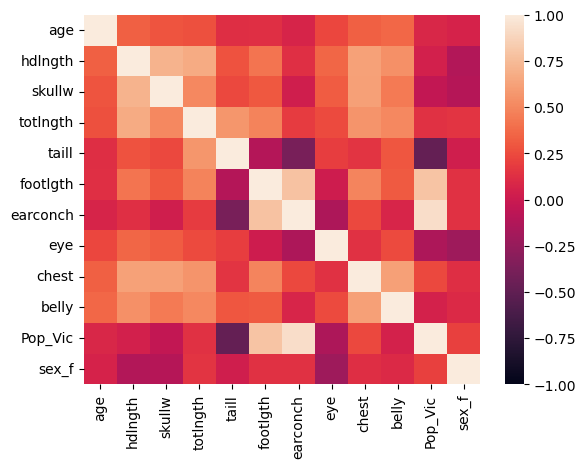

In [133]:
sns.heatmap(df.corr(), vmin=-1, vmax=1, )
plt.tight_layout

We note that there is anything from a weak to a strong correlation between most of the predictors here, hence there is substantial multi-collinearity. We anticipate that shrinkage methods like ridge and lasso regression will be useful here.

We'll now split our data into a training and test set before proceeding.

In [134]:
# Split into training and testing samples

random.seed(seed)
test_indices = random.sample(range(df.shape[0]), df.shape[0]//5 ) # Obtain indcies for test sample
df_test = df.iloc[test_indices]
df_test.reset_index(inplace=True, drop=True) # Reset indicies for later use
df_train = df.drop(test_indices, axis=0)
df_train.reset_index(inplace=True, drop=True)

# Extract the target variable

y = df_train['hdlngth']
y_test = df_test['hdlngth']
X = df_train.drop(['hdlngth'], axis=1)
X_test = df_test.drop(['hdlngth'], axis=1)

<a name="q11"></a>

## 1.1 Linear Regression  [^](#outline)

Linear regression is the simplest machine learning model there is. It begins with a dataset of observations, each observation being some linear combination of predictors. We will represent this by an $n \times p$ matrix $\textbf{X}$ for $n$ observations and $p$ predictors. We then have a target variable $\mathbf{y}$ which is a $n$-vector of corresponding targets to our dataset. The goal is to predict some new observation $y$ from an unseen observation $\mathbf{x}_i$. In practice, this new observation will come from the test set of our data. To this end we make a prediction, $\mathbf{\hat{y}}$, of the form $\mathbf{\hat{y}}=\mathbf{X}\boldsymbol{\beta}$ for some vector of parameters $\boldsymbol{\beta}$. Thus, a single prediction can be written as 
$$
\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip}
$$
Our predictions thus produce errors which we call residuals (defined by $y_i - \hat{y}_i$) and we seek to minimise the RSS (residual sum of squares)  these. We can thus formulate our problem as the optimisation problem
$$
\min_{\boldsymbol{\beta}} || \mathbf{y} - \mathbf{X}\boldsymbol{\beta} ||^2
$$
Computing the gradient we have
$$
\nabla_{\boldsymbol{\beta}} f(\boldsymbol{\beta}) = -2\mathbf{X}^T(\mathbf{y}-\mathbf{X}\boldsymbol{\beta})
$$
where here we have set $f(\mathbf{X}) = || \mathbf{y} - \mathbf{X}\boldsymbol{\beta} ||^2 $. Now setting the gradient to $\mathbf{0}$ we have
$$ \boldsymbol{\beta} = \big( \mathbf{X}^T \mathbf{X} \big)^{-1} \mathbf{X}^T\mathbf{y} $$
Note that this can simplify to
$$
\boldsymbol{\beta} = \mathbf{X}^{-1} \mathbf{y}
$$
which can be computed directly only if $\mathbf{X}^{-1}$ exists. This is typically not the case. If it does not, we must compute the full expression above. We can verify that this is indeed a minimum by examining the Hessian,
$$
\nabla^2_{\boldsymbol{\beta}} = \mathbf{X}^T\mathbf{X}
$$
which is positive-definite assuming $\mathbf{X}\neq\mathbf{0}$. Thus our answer is indeed a minimum.

We'll now fit the linear model. For this first model, we will not standardise it order to preserve interpretability. We do define a standardisation function to use later though. We fit the model below and print the coefficients.

In [142]:
def standardise(X):
    '''
    Standardises a dataset, i.e. returns (X - mu) / sigma

    INPUTS:
    X - an n x p array or dataframe consisting of n observations with p predictors

    OUTPUT:
    the standardised version of that array
    '''
    
    mu = np.mean(X, 0)
    sigma = np.std(X, 0)
    X_std = (X-mu)/(sigma)
    return X_std

def coefficients(X, y):
    '''
    Computes the OLS regression coefficients

    INPUTS:
    X - N x D matrix of training inputs
    y - N x 1 vector of training targets/observations

    OUTPUS:
    OLS coefficients (D x 1) array
    '''
    
    beta = np.linalg.pinv(X) @ y
    return beta

# Add an intercept term to our model matrix

N = X.shape[0]
X_int = np.hstack([np.ones((N,1)), X])

# Obtain the coefficients and predicted response

beta = coefficients(X_int, y)
y_pred = X_int @ beta

# Print the model parameters

print(beta)

[22.132724    0.15413311  0.25502796  0.34700857 -0.49177434  0.22675171
  0.32126567  0.3305025   0.11505667  0.20802228 -4.82547754 -0.86395417]


We make a few observations about the coefficients. It appears the majority of the coefficients are positively correlated with head length. This should make sense, most of them are other length measurements like foot or tail length. We'd expect age to be positively correlated with head length too. One of the few that is negative is the last coefficient, corresponding to the effect of being female. We see that female possums typically have smaller head lengths than that of males by about 0.864mm. We note that possums belonging to the Victoria population have substantially smaller heads too, by about 4.83mm.

We now calculate the $R^2$ statistic using a pre-defined function.

In [143]:
def R_squared(y, y_pred):
    '''
    Computes the R^2 statistic

    INPUTS:
    y - an n x 1 array of true values
    y_pred - an n x 1 array of predicted values from a model

    OUPUTS:
    R - the R^2 statistic
    '''
    
    y_bar = np.mean(y)
    SST = np.sum((y-y_bar)**2)    # Sum of squares total, i.e. the variance of the target variable
    SSE = np.sum((y-y_pred)**2)   # Sum of squared errors
    R = 1 - SSE/SST
    return R

r2_score_train = R_squared(y, y_pred)
print(f'{r2_score_train: .1%}')

 69.2%


From this result it appears the model describes a moderately-high portion of the variance. We now proceed to apply the model to the test data and compare.

In [144]:
# Add an intercept term

N = X_test.shape[0]
X_test_int = np.hstack([np.ones((N,1)), X_test])

# Obtain the prediction

y_pred_test = X_test_int @ beta
r2_score_test = R_squared(y_test, y_pred_test)
print(f'{r2_score_test : .1%}')

 81.0%


The $R^2$ statistic for the test set is also reasonably good, surprisingly better than the training set. This suggests that the model was not overfitted to the training data and so retains its predictive power on unseen data.

Let's now compare our model coefficients with a simple linear regression model using sci-kit learn.

In [145]:
model = LinearRegression()
model.fit(X, y)
print(f'R2 score from sklearn on training data: {r2_score(y, model.predict(X)) : .1%}' )
print(f'R2 score from numpy model on training data: {r2_score_train : .1%}')
print(f'R2 score from sklearn on test data: {r2_score(y_test, model.predict(X_test)) : .1%}' )
print(f'R2 score from numpy model on test data: {r2_score_test : .1%}')

R2 score from sklearn on training data:  69.2%
R2 score from numpy model on training data:  69.2%
R2 score from sklearn on test data:  81.0%
R2 score from numpy model on test data:  81.0%


A perfect comparison!

<a name="q12"></a>
## 1.2 Ridge Regression[^](#outline)

In this section we will not attempt to refine our ordinary least squares problem by using ridge regression. Ridge regression is the same as OLS but with the addition of a penalty term (given by an $l_2$ norm) on the coefficients. This thus acts to shrink the coefficients. Naturally, this increases the bias of the model but it also decreases the variance. Thus, controlling the multiple of the penalty term allows us to tune our model to avoid overfitting; we have no such control in OLS regression. The ridge regression coefficients are thus the solution to the optimisation problem
$$
\min_\boldsymbol{\beta} ||\mathbf{y} - \mathbf{X}\boldsymbol{\beta} ||^2_2 + \lambda || \boldsymbol{\beta }||_2
$$
where $\lambda$ is a hyperparameter to be tuned later. The problem is solved similarly as to before by computing the gradient. We need only add an additional term due to the penalty function:
$$
\nabla_{\boldsymbol{\beta}}f = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}  + 2\lambda\boldsymbol{\beta}
$$
We see that this is $\mathbf{0}$ when
$$
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X}+ \lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}
$$
Similarly, the Hessian in this case is just
$$
\nabla^2_{\boldsymbol{\beta}}f = \mathbf{X}^T\mathbf{X} + 2\lambda \mathbf{I}
$$
which is also positive definite assuming both $\mathbf{X}\neq\mathbf{0}$ and $\lambda>0$.

We'll now begin to fit the model by defining a function to compute the ridge estimate given a penalty term. We must first standardise the predictors since without doing so will unfairly penalise predictors with larger scales. By standardising both the predictor and response variables we remove the need for an intercept term. However, a consequence is that we now have one less predictor in our model so a simple $R^2$ statistic is likely to be worse compared with a model which includes one. We will thus use MSE as our metric for comparison. We will also refit our OLS model later for comparison.

In order to tune our hyperparameter, we then use 5-fold cross validation to tune the hyperparameter.

In [146]:
X = standardise(X)
X_test = standardise(X_test)
y = standardise(y)
y_test = standardise(y_test)

def beta_ridge(X,y,lam):
    '''
    Computes the ridge regression coefficients

    INPUTS:
    X - an n x p array of observations
    y - an n x 1 array of corresponding observations
    lam - the hyperparameter corresponding to the penalty term

    OUTPUTS:
    an p x 1 array of ridge regression coefficients
    '''

    N, M = X.shape
    
    # Calculate the parameters
    
    I = np.identity(M)
    beta = (np.linalg.inv(X.T @ X + lam * I)) @ X.T @ y
    
    return beta

# Create the folds

folds = np.array_split(np.arange(len(y)), 5)

We wish to score each of these folds using the mean square error so we define a function to do this. We then define a function which produces the mean score of given folds. After this, a function is written to seek the best possible choice of lambda.

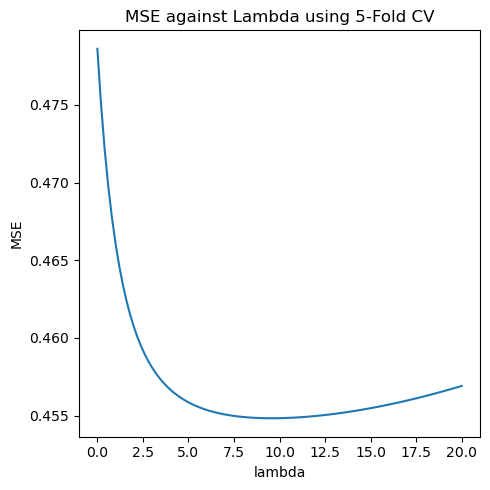

In [147]:
def MSE(y, y_pred):
    '''
    INPUTS:
    y - the observed response
    y_pred - the predicted response from the model

    OUTPUTS:
    MSE - the mean squared error of the prediction
    '''
    
    MSE = np.sum((y-y_pred)**2)/len(y)
    return MSE

def folds_score(X, y, folds, lam):
    '''
    INPUTS:
    X - matrix of training data of predictor variables
    y - vector of training data on response variable
    folds - indices containing each of the folds to implement cross-validation
    lam - a choice of the tuning parameter lambda in ridge regression

    OUTPUTS:
    MSE - the average mean squared error on the data given the choice of lambda across the folds
    '''

    # Initialise variables
    
    score = 0
    N = len(folds)

    # Iterate over the number of folds
    
    for i in range(N):

            # Begin by obtaining the indicies for a given fold and select the relevant observations in the dataset
        
            val_indexes = folds[i]
            X_val = X.iloc[val_indexes]
            y_val = y[val_indexes]
            X_train = X.drop(val_indexes, axis=0)
            y_train = y.drop(val_indexes, axis=0)

            # Obtain the ridge parameters on the training data
    
            beta = beta_ridge(X_train, y_train, lam)

            # Obtain the prediction and add the MSE for a single fold to a running tally over all the folds
        
            y_pred = np.array(X_val) @ beta
            score += MSE(y_val, y_pred)

    # Average the MSE from each fold
        
    score = score/N
    return score

# Perform a simple grid search over lambda in the interval [0,0.1] in 0.001 increments

lam = np.linspace(0,20,101)
lam_scores = np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = folds_score(X, y, folds, lam[i])

# Produce a plot

fig, ax = plt.subplots(figsize=(5,5), tight_layout=True)
ax.plot(lam, lam_scores)
ax.set_title('MSE against Lambda using 5-Fold CV')
ax.set_xlabel('lambda')
ax.set_ylabel('MSE')
plt.show()

From the above plot it is clear that ridge regression greatly reduces the MSE compared with OLS. We will now obtain the optimum value for $\lambda$ and compare both train and test MSEs for both ridge and OLS alongside their $R^2$ score.

In [148]:
# Find optimum lambda

lam_optimum = lam[np.argmin(lam_scores)]
print(f'MSE is minimised when lambda is {lam_optimum : .3}')

MSE is minimised when lambda is  9.6


In [149]:
# Obtain MSE scores for the original OLS model

beta = coefficients(X, y)
y_pred = X @ beta
y_pred_test = X_test @ beta

r2_score_train = R_squared(y, y_pred)
r2_score_test = R_squared(y_test, y_pred_test)
MSE_train = MSE(y, y_pred)
MSE_test = MSE(y_test, y_pred_test)

# Obtain training scores for the ridge model

beta = beta_ridge(X, y, lam_optimum)
y_pred = np.array(X) @ beta
y_pred_test = np.array(X_test) @ beta

r2_score_train_ridge = R_squared(y, y_pred)
r2_score_test_ridge = R_squared(y_test, y_pred_test)
MSE_train_ridge = MSE(y, y_pred)
MSE_test_ridge = MSE(y_test, y_pred_test)

# Print the results

print(f'R2 scores on the training data are {r2_score_train : .1%} for OLS and {r2_score_train_ridge : .1%} for ridge')
print(f'R2 scores on the test data are {r2_score_test : .1%} for OLS and {r2_score_test_ridge : .1%} for ridge')
print(f'MSE on the training data is {MSE_train : .3} for OLS and {MSE_train_ridge : .3} for ridge')
print(f'MSE on the test data is {MSE_test : .3} for OLS and {MSE_test_ridge : .3} for ridge')


R2 scores on the training data are  69.2% for OLS and  66.8% for ridge
R2 scores on the test data are  79.0% for OLS and  80.3% for ridge
MSE on the training data is  0.308 for OLS and  0.332 for ridge
MSE on the test data is  0.21 for OLS and  0.197 for ridge


We see from above that the ridge regression performs a small margin worse on the training data than OLS. This should be expected as the introduction of a ridge parameter increases the bias but decreases the variance. Note that in this case we refitted the OLS model using the standardised data and thus did not include an intercept term. This allows for a fair comparison between OLS and ridge regression. We see that for the training data the $R^2$ statistic is worse for ridge but the test set performance is superior. The same pattern is noted for MSE and we see an approximate $1 - 0.197/0.21 \approx 6\%$ reduction in MSE from using ridge regression.

<a name="q13"></a>

## 1.3 Lasso Regression[^](#outline)

In this section we will now implement  Lasso regression, a further modification to OLS regression. Standard Lasso regression introduces an $l_1$ penalty and takes the form
$$
\min_{\boldsymbol{\beta}} \bigg( ||\mathbf{y} - \mathbf{X}\boldsymbol{\beta} ||^2_2 + \lambda || \boldsymbol{\beta} ||_1 \bigg)
$$
where $|| \boldsymbol{\beta} ||_1 = \sum_{i=0}^n |\beta_i| $.
The problem can be solved using gradient descent methods. If we let $L(\boldsymbol{\beta})$ denote the loss function above which we are trying to minimise, then it is easy to see that the gradient is
$$
\nabla_{\boldsymbol{\beta}} = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} + \lambda \mathbf{sgn}(\boldsymbol{\beta})
$$
where here, we have defined $\mathbf{sgn}$ to be the vector generalisation of the sign function so that $\mathbf{sgn}(\mathbf{x})=\text{sgn}(x_i)\mathbf{e}_i$, i.e., it returns the sign of each component of the vector.

We begin this section by writing a functions which calculates the gradient above.

In [152]:
def grad_l1(beta):
    '''
    Computes the vector generalisation of the sgn function (as defined above)

    INPUTS:
    beta - a p x 1 array of coefficients

    OUPUTS:
    p x 1 array corresponding to the gradient of the input
    '''
    
    p = len(beta)
    grad = np.zeros(p)
    
    for i in range(p):
        if beta[i] < 0 :
            grad[i] = -1
        elif beta[i] > 0 :
            grad[i] = 1
        else:
            grad[i] = 0
    return grad

assert np.all(np.equal( grad_l1(np.array([5,1,-1,0])),  np.array([1,1,-1,0]) ))

We now write a function for minimising the cost function using gradient descent methods. We use a default step size of 0.001 during this process.

In [153]:
def minimize_lasso(X, y, lam, n_iters=10000, step_size=1e-3):
    '''
    Computes the lasso regression coefficients using gradient descent methods

    INPUTS:
    X - an n x p array of observations
    y - an n x 1 array of corresponding targets
    lam - the lasso penalty hyperparameter
    n_iters - the number of gradient descent iterations to use
    step_size - the size of each step in the gradient descent algorithm

    OUTPUTS:
    beta - a p x 1 array of lasso regression coefficients
    '''
    n, p = X.shape
    XX = X.T @ X  # removed the / n portion
    Xy = X.T @ y 
    
    # Initialise betas
    beta = np.zeros(p)

    # Gradient descent
    for i in range(n_iters):
        grad = -2*Xy + 2*XX@beta + lam*grad_l1(beta)
        
        # Gradient descent update
        beta = beta - grad*step_size
      
    return beta

We now use 5-fold cross validation to tune the hyperparameter lambda as before.

In [154]:
def folds_lasso_score(X, y, folds, lam):
    '''
    Employs cross validations on a dataset to obtain the average MSE for lasso regression
    
    INPUTS:
    X - an n x p array of observations
    y - an n x 1 array of corresponding targets
    folds - a list of lists of indices containing corresponding to the folds to use
    lam - the lasso penalty hyperparameter

    OUTPUS:
    The averaged MSE across each of the folds
    '''
    
    score = 0
    N = len(folds)
    
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Add an intercept term
            
            p, q = X_train.shape[0], X_val.shape[0]
            #X_train_aug = np.hstack([np.ones((p,1)), X_train])
            #X_val_aug = np.hstack([np.ones((q,1)), X_val])
            
            # Obtain the lasso parameters on the training data
    
            beta = minimize_lasso(X_train, y_train, lam)
    
            # Obtain prediction
    
            y_pred = X_val @ beta
            fold_MSE = MSE(y_val, y_pred)
            score += fold_MSE
        
    score = score/N
    return score

In [155]:
# Create the folds
folds = np.array_split(np.arange(len(y)), 5)

# Scan over a range of values for lambda
lam = np.linspace(0,2,21)
lam_scores = np.zeros(len(lam))

for i in range(len(lam)):
    lam_scores[i] = folds_lasso_score(np.array(X), y, folds, lam[i])

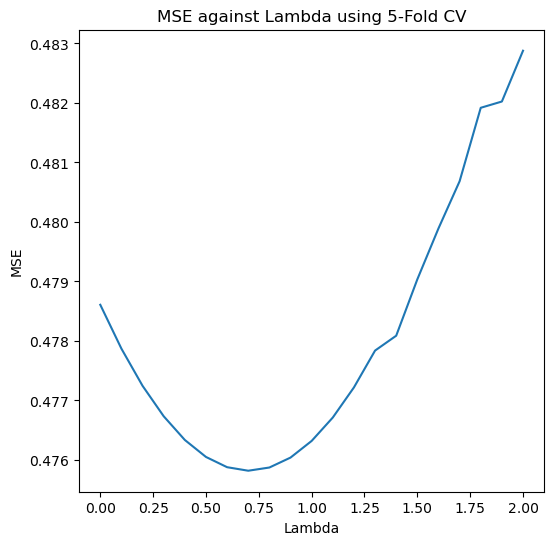

In [156]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(lam, lam_scores)
ax.set_title('MSE against Lambda using 5-Fold CV')
ax.set_xlabel('Lambda')
ax.set_ylabel('MSE')
plt.tight_layout
plt.show()

From the above plot, the optimal choice of $\lambda$ appears to be about 0.7. We now examine the in and out of sample $R^2$ and MSE scores with this choice of $\lambda$.

In [157]:
lam = lam[np.argmin(lam_scores)]
print(f'{lam : .3}')

 0.7


In [159]:
beta = minimize_lasso(np.array(X), y, lam)
y_pred = X @ beta
MSE_lasso = MSE(y_pred, y)
r2_score_train_lasso = R_squared(y, y_pred)

y_pred = X_test @ beta
MSE_lasso_test = MSE(y_pred, y_test)
r2_score_test_lasso = R_squared(y_test, y_pred_test)

beta = coefficients(X_int, y)
y_pred = X_int @ beta
MSE_OLS = MSE(y_pred, y)

y_pred = X_test_int @ beta
MSE_OLS_test = MSE(y_pred, y_test)

print(f'MSE on training data for OLS is {MSE_train : .3}')
print(f'MSE on training data for Lasso is {MSE_lasso : .3}')
print(f'MSE on test data for OLS is {MSE_test : .3}')
print(f'MSE on test data for Lasso is {MSE_lasso_test : .3}')
print(f'R2 scores on the training data for OLS is {r2_score_train : .1%}')
print(f'R2 scores on the training data for Lasso is {r2_score_train_lasso : .1%}')
print(f'R2 scores on the test data for OLS is {r2_score_test : .1%}')
print(f'R2 scores on the test data for Lasso is {r2_score_test_lasso : .1%}')


MSE on training data for OLS is  0.308
MSE on training data for Lasso is  0.309
MSE on test data for OLS is  0.21
MSE on test data for Lasso is  0.202
R2 scores on the training data for OLS is  69.2%
R2 scores on the training data for Lasso is  69.1%
R2 scores on the test data for OLS is  79.0%
R2 scores on the test data for Lasso is  80.3%


As with the ridge regression, we see worse performance on the training dataset for Lasso for both $R^2$ and MSE as expected. However, the test set $R^2$ and MSE are substantially better with an approximate $4%$ reduction in MSE for the Lasso model.

Across all three methods, ridge produced the most accurate predictions having an $R^2$ statistic of 80.3% on the test set, the same as Lasso but with a lower MSE of 0.197.

<a name="task-2"></a>

# Task 2: Classification [^](#outline)

<a name="q21"></a>

## 2.1 kNN Classifier [^](#outline)

The premise of a kNN Classifier is simple. Let our training data consist of $n$ observations of $p$ predictors via the matrix $\mathbf{X}$. Suppose each observation has a corresponding binary classification given by the vector $\mathbf{y}$. Then, for some new observation, $x^T$, we select the $k$ closest observations from $X$ and compute the modal class amongst those $k$ (or mean for regression tasks). The idea of closeness can use any metric, although we typically use the $l_2$ norm, i.e.
$$
|| \mathbf{a} - \mathbf{b}||_2 = \sum_{i=1}^p (a_i-b_i)^2
$$

In this section we implement a k-nearest neighbours function for classification. We first load in the data and standardise it. The standardisation is essential because without it, predictors with larger quantities will always be deemed further away by the Euclidean metric. Upon inspecting the data, we can see that the 1st column is just an index for the sample so we remove this. We then change the diagnosis columns to 0's and 1's. This means that when the probability of a sample being malignant can easily be classified by rounding to the nearest integer.

In [3]:
path_heart_disease = kagglehub.dataset_download("oktayrdeki/heart-disease", output_dir="D:\jupyter\data", force_download=True)
df = pd.read_csv(str(path_heart_disease)+"\heart_disease.csv")
pd.set_option("display.max_columns", None)
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [ ]:
df.isna().sum()

Our source for the dataset provides no information as to why there are missing values or if they have any particular meaning so we'll assume they are simply missing. For any quantiative predictors, we will fill them using the mean for each predictor and for categorical data, we'll use the mode.

In [3]:
# Get indices for both types of predictors
quantitative_predictors = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
categorical_predictors = df.columns.drop(quantitative_predictors)

# Fill the quantitative nan's with the respective means
df_quant = df[quantitative_predictors].fillna(df[quantitative_predictors].mean())

# Use a dictionary before calling fillna() for categorical data
values = df[categorical_predictors].mode().iloc[0]
keys = categorical_predictors
categorical_dict = {k:v for k,v in zip(keys, values)}
df_cat = df[categorical_predictors].fillna(categorical_dict)

# Join all the predictors back again
df = df_quant.join(df_cat)

We'll now start by one-hot encoding the categorical variables. We'll choose which column to eliminate by hand to make coefficients more interpretable. For instance, its seems more sensible to choose Exercise Habits_Low as the reference point, so one can interpret the affects of addditional levels of exercise.

In [4]:
df = pd.get_dummies(df, dtype=int)
indices = df.columns[[9,12,14,16,18,20,22,24,27,30,33,35]]
pd.get_dummies(df, dtype=int)
df = df.drop(indices, axis=1)

We'll now split the data into a training and a test set using an 80/20 split.

In [8]:
# Separate target variable

X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

# Split the data

X, X_test, y, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed, shuffle=True)

# Standardise the predictor variables using the mean and std of the training data

X = ( X - X.mean() ) / X.std()
X_test = ( X_test - X.mean() ) / X.std()

We now define the necessary functions for a KNN classifier.

In [9]:
# Function to measure Euclidean distance

def euclidean_distance(p, q):
    '''
    Takes 2D arrays and returns the euclidean distance between each vector in the array

    Inputs:
    p : a 2D numpy array
    q : a 2D numpy array

    Output:
    The euclidean distance for every pair of rows in x and y
    '''
    return np.sqrt(((q-p)**2).sum(axis=1))

# Find the k-nearest neighbours

def k_neighbours(X_train, X_val, k=5, return_distance=False):
    '''
    Finds the k-nearest neighbours to each entry in a validation set

    INPUTS:
    X_train : The data on which the model is trained. The nearest neighbours will be selected from this set
    X_val : The set of new inputs, each of which we are trying to find the k-nearest neighbours
    k : The number of neighbours to select
    return_distance : Boolean, gives the option to return the distance of each neighbour as well

    OUTPUTS:
    neigh_ind : a 2D numpy array containing the indices of each of the nearest neighbours
    '''
    
    dist = []
    neigh_ind = []
  
    # Compute distance from each point x in the validation set to all points in the training set
    
    N = X_val.shape[0]
    point_dist = [euclidean_distance(X_val[n,:], X_train) for n in range(N) ]

    # Determine which k training points are closest to each validation point
    
    for row in point_dist:
    
        enum_neigh = enumerate(row)
        sorted_neigh = sorted(enum_neigh, key=lambda x: x[1])[:k]

        ind_list = [tup[0] for tup in sorted_neigh]
        dist_list = [tup[1] for tup in sorted_neigh]

        dist.append(dist_list)
        neigh_ind.append(ind_list)

        # Return distances together with indices of k nearest neighbours
        
        if return_distance:
            return np.array(dist), np.array(neigh_ind)
    return np.array(neigh_ind)

# Define a function for classifying the data

def predict(X_train, y_train, X_test, k=5):
    '''
    Given training data, returns the predicted class on a set of new inputs

    INPUTS:
    X_train : a 2D numpy array, each row consisting of a single observation of the training data for the classifier
    y_train : a 1D numpy array corresponding to the target classification
    X_test : a 2D numpy array, each row consisting of a single observation of the new data to classify
    k : the number of neighbours to use, default is 5

    OUTPUT:
    y_pred : a 1D numpy array of the predicted classes on the test set
    '''
    
    # Obtain the k-nearest neighbours
    
    neighbours = k_neighbours(X_train, X_test, k=k)
    
    # Count number of occurences of label with np.bincount and choose the label that has most with np.argmax
    
    M = len(neighbours)
    y_pred = np.array([ np.argmax(np.bincount(np.array(y_train[neighbours[m]], dtype=int))) for m in range(M)])
    return y_pred

# Define a score function

def score(X_train, y_train, X_test, y_test, k=5):
    '''
    Returns the accuracy of the KNN model given training and test sets

    INPUTS:
    X_train : a 2D numpy array of training data, each row being one observation
    y_train : a 1D numpy array of the corresponding response variable
    X_test : a 2D numpy array of the test data, each row being one observation
    y_test : a 1D numpy array of the corresponing response variable to the test data
    k : the number of neighbours to use in the KNN algorithm, default is 5

    OUTPUTS:
    acc - the accuracy of the model
    recall - the recall of the predictions
    precision - the precision of the predictions
    f1_score - the harmonic mean of recall and precision
    '''
    y_pred = predict(X_train, y_train, X_test, k=k)

    TP = np.sum( (y_pred == y_test) & (y_test==1) )
    TN = np.sum( (y_pred == y_test) & (y_test==0) )
    FP = np.sum( (y_pred != y_test) & (y_test==0) )
    FN = np.sum( (y_pred != y_test) & (y_test==1) )

    acc = np.mean(y_pred==y_test)
    recall = TP / (TP + FN)
    precision = TP / (TP + FP)
    f1_score = ( 2*recall*precision ) / ( recall + precision ) 
    
    return [acc, recall, precision, f1_score]

# Define a score for cross validation

def cross_validation_score(X_train, y_train, folds, k):
    '''
    Returns the mean accuracy score after implementing k-folds cross validation

    INPUTS:
    X_train : a 2D numpy array of training data, each row being one observation
    y_train : a 1D numpy array of the corresponding response variable
    folds : a 2D numpy array, each row consisting of a list of indices of a single fold
    k : the number of neighbours

    OUTPUTS:
    The mean accuracy across each of the folds
    '''
    
    scores = []
    for i in range(len(folds)):
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))
    
        X_val_i = X_train[val_indexes]
        y_val_i = y_train[val_indexes]

        X_train_i = X_train[train_indexes]
        y_train_i = y_train[train_indexes]
        
        score_i = score(X_train_i, y_train_i, X_val_i, y_val_i, k=k)
        scores.append(score_i)

        # Return the average score
        ans = np.mean(scores, axis=0)
        
        return ans
    
# Define the folds

folds = np.array_split(np.arange(len(y)), 5)

# Grid search for optimal value of k

def choose_best_k(X_train, y_train, folds, k_range):
    '''
    Performs a grid search for the optimum value of k using accuracy as the metric to maximise

    INPUTS:
    X_train : a 2D numpy array of training data, each row being one observation
    y_train : a 1D numpy array of the corresponding response variable
    folds : a 2D numpy array, each row consisting of a list of indices of a single fold
    k_range : a 1D numpy array of different values of k to search over

    OUTPUT:
    The optimal choice of k
    '''
    k_scores = [] 
    
    for i, k in enumerate(k_range):
        k_scores.append( cross_validation_score(X_train, y_train, folds, k) )
        print(f'For {k} neighbours, accuracy = {k_scores[i][0]:.3f}, recall = {k_scores[i][1]:.3f}, precision = {k_scores[i][2]:.3f}, f1 = {k_scores[i][3]:.3f} ')

        # Select best k based on accuracy
        
        best_k_index = np.argmax([score[0] for score in k_scores])
    return k_range[best_k_index]

Now we tune the model to the training data.

In [11]:
best_k = choose_best_k(np.asarray(X), np.asarray(y), folds, np.arange(1, 11))
print('best_k:', best_k)

For 1 neighbours, accuracy = 0.668, recall = 0.203, precision = 0.191, f1 = 0.197 
For 2 neighbours, accuracy = 0.772, recall = 0.041, precision = 0.186, f1 = 0.067 
For 3 neighbours, accuracy = 0.738, recall = 0.103, precision = 0.200, f1 = 0.136 
For 4 neighbours, accuracy = 0.786, recall = 0.034, precision = 0.250, f1 = 0.060 
For 5 neighbours, accuracy = 0.777, recall = 0.087, precision = 0.301, f1 = 0.136 
For 6 neighbours, accuracy = 0.799, recall = 0.037, precision = 0.480, f1 = 0.070 
For 7 neighbours, accuracy = 0.788, recall = 0.044, precision = 0.298, f1 = 0.076 
For 8 neighbours, accuracy = 0.796, recall = 0.013, precision = 0.267, f1 = 0.024 
For 9 neighbours, accuracy = 0.792, recall = 0.025, precision = 0.276, f1 = 0.046 
For 10 neighbours, accuracy = 0.798, recall = 0.006, precision = 0.286, f1 = 0.012 
best_k: 6


It appears from the above that the optimal value for $k$ is 6 although we note that both recall and F1 scores are maximised with $k=1$ neighbour. We will return to this later. We now train the model with $k=6$ and test it on both the training and the test data.

In [18]:
print( f'Training scores: {score(np.asarray(X), np.asarray(y), np.asarray(X), np.asarray(y), k=best_k) }')
print( f'Test scores: {score(np.asarray(X), np.asarray(y), np.asarray(X_test), np.asarray(y_test), k=best_k) }')

Test scores: [np.float64(0.80325), np.float64(0.056416615003099815), np.float64(0.6363636363636364), np.float64(0.10364464692482915)]
Test scores: [np.float64(0.8065), np.float64(0.0), np.float64(nan), np.float64(nan)]


C:\Users\ccbar\AppData\Local\Temp\ipykernel_12396\2602676607.py:113: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


Overall we obtained 81% accuracy on the test data however the recall was 0 indicating that all positive cases were indeed missed. Indeed, the null rate in the original dataset was 80% so any predictor which always defaults to predicting an observation as not having heart disease will be correct 80% of the time. We will address this shortly.

## Comparison with Sci-Kit Learn Model

Here, we will fit a KNN classifier using sci-kit learn and measure its performance as compared with our own model.

In [22]:
# Define the model

model = KNeighborsClassifier( n_neighbors = 6 )

# Scale the data

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

# Fit the model

model.fit(X, y)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred )

0.8065

We see that our model obtains exactly the same as the sci-kit learn model.

## Addressing the Imbalanced Dataset

Up to this point we have successfully implemented a kNN algorithm from scratch which is comparable to sci-kit learn models and we have optimised our hyperparameter such that the accuracy of our model approaches approximately 80%. There is a significant issue with this however. The original dataset had only 20% of the observations consisting of individuals with observations. The remaining 80% did not. Thus, the null rate is 80%, i.e., any model which always predicts someone as not having heart disease will be correct 80% of the time. Thus our model is not much better than this. One way we could do this is to tune our hyperparameter for a more relevant metric like recall but another method is to use SMOTE (synthetic minority oversample technique)

In [23]:
# Separate target variable

X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

# Create a train-test split before oversampling

X, X_test, y, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed, shuffle=True)

# Create a balanced dataset by oversampling from the minority class

n = np.sum(y) # number of heart disease individuals
m = y.shape[0] - n # number of non-heart disease samples

# Oversample the minority class

X = pd.concat( [ X, X[y==1].sample( (m-n), replace=True, random_state=seed) ] )
X.reset_index()

# Add them on to the response vector as well
y = pd.concat([y, pd.Series(np.ones(m-n))])
y.reset_index

# Standardise the predictor variables using the mean and std of the training data

X = ( X - X.mean() ) / X.std()
X_test = ( X_test - X.mean() ) / X.std()

# Define the folds

folds = np.array_split(np.arange(len(y)), 5)

best_k = choose_best_k(np.asarray(X), np.asarray(y), folds, np.arange(1, 6))

print('best_k:', best_k)

For 1 neighbours, accuracy = 0.779, recall = 0.975, precision = 0.474, f1 = 0.638 
For 2 neighbours, accuracy = 0.770, recall = 0.865, precision = 0.460, f1 = 0.600 
For 3 neighbours, accuracy = 0.620, recall = 0.896, precision = 0.332, f1 = 0.485 
For 4 neighbours, accuracy = 0.643, recall = 0.759, precision = 0.329, f1 = 0.459 
For 5 neighbours, accuracy = 0.559, recall = 0.829, precision = 0.289, f1 = 0.429 
best_k: 1


Here, we have obtained a much more useful model. The accuracy is highest for $k=1$ in a comparable manner to our previous model except this time the recall, precision and F1 score are far superior. We now test our model's performance on the test set.

In [25]:
print( f'Training scores: {score(np.asarray(X), np.asarray(y), np.asarray(X), np.asarray(y), k=best_k) }')
print( f'Test scores: {score(np.asarray(X), np.asarray(y), np.asarray(X_test), np.asarray(y_test), k=best_k) }')

Test scores: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
Test scores: [np.float64(0.641), np.float64(0.2997416020671835), np.float64(0.20603907637655416), np.float64(0.2442105263157895)]


Overall, our 2nd model has a much lower accuracy score of 64% but both the recall (0.300) and F1 score (0.244) are far superior to the previous model which obtained 0.056 and 0.104 respectively. Nonetheless, the score remains disappointing.

<a name="q22"></a>

## 2.2 Random Forest [^](#outline)

In this section we will train a random forest for classification. The concept of a random forest begins with a simple decision tree. A single decision tree takes an input $\mathbf{x}_i \in \mathbb{R}^p$ and chooses a split $t$ based on a single predictor such that every object is then divided into two categories. Thus our dataset is divided into $\mathbf{x}_i$ s.t. $x_{ij} < t$ and $\mathbf{x}_i$ s.t. $x_{ij}\geq t$ where $t$ is the threshold at which the split is made across the $j^{\text{th}}$ predictor. We now have two sub-regions, call them $X_1, \, X_2$. This process is repeated until a stopping criteria is reached, such as there being less than some number of observations in a single region or a max number of regions is reached. Once we have obtained our regions $X_1, \, X_2, \dots X_s$ we then predict each observation to be the modal response in each region. The optimal split at each stage is defined to be the one which minimises some loss function at that stage. Thus, the decision tree algorithm is <i>greedy</i>. In our case, we will choose to minimise the <i>cross-entropy</i> which, for a given region $X_r$, is given by
$$
-\sum_{k=1}^K p_r^{(k)} \log (1 - p_r^{k}). 
$$
Here, $K$ denotes the number of classes and $k$ the given class an observation belongs too. The probability that an element belongs to class $k$ given it is in region $r$ is given by
$$
p_r^{(k)} = \frac{\sum_{i=1}^n \mathbb{I}_{\mathbf{x}_i \in X_r} \mathbb{I}_{y_i = k}}{\sum_{i=1}^n \mathbb{I}_{\mathbf{x}_i \in X_r}}.
$$
More specifically, we choose the split such that the resulting weighted sum of the cross-entropy across the two new sub-regions (weighted by the number of observations in each sub-region) is reduced maximally.

Once we have a simple decision tree, we can implement <i>bagging</i>. The idea here is that we instead produce $N$ decision trees, each trained on a bootstrapped sample from the original dataset (a random sample from the dataset which allows for replacement). To obtain a prediction, we simply take the mean or modal response from the $N$ trees depending on whether it is a classification or a regression task. A random forest is the same, with the exception that at each split, a random subset of the predictors is chosen from in order to prevent a single predictor from dominating the decision tree.

We begin by loading in the data and obtaining the feature names which is needed as an input later on.

In [108]:
df = pd.read_csv('data/tumour_samples.csv')
df.drop(df.columns[0], axis=1, inplace=True)

X = df.drop(columns='DIAGNOSIS')
feature_names = X.columns.tolist()
y = df['DIAGNOSIS']
y.replace('M', 1, inplace=True)
y.replace('B', 0, inplace=True)
X = np.asarray(X)
y = np.asarray(y)

df = pd.read_csv('data/tumour_test.csv')
df.drop(df.columns[0], axis=1, inplace=True)

X_test = df.drop(columns='DIAGNOSIS')
y_test = df['DIAGNOSIS']
y_test.replace('M', 1, inplace=True)
y_test.replace('B', 0, inplace=True)
X_test = np.asarray(X_test)
y_test = np.asarray(y_test)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\2464660254.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace('B', 0, inplace=True)
C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\2464660254.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test.replace('B', 0, inplace=True)


In [5]:
# Obtain the data

X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

# Obtain feature names; this will be needed later on
feature_names = X.columns.tolist()

# Split the data

X, X_test, y, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed, shuffle=True)

# Convert the data to an array for ease of use

X = np.asarray(X)
y = np.asarray(y)
X_test = np.asarray(X_test)
y_test = np.asarray(y_test)

In [109]:
X_small = X[:200, :]
y_small = y[:200]
X_test_small = X_test[:200,:]
y_test_small = y_test[:200]

folds_small = np.array_split(np.arange(len(y_small)), 5)

We now define several functions. The first measures the cross entropy. The second splits the samples given a column to split about and a value for the split. The next function finds the optimum split value given a feature and the one after finds the optimum split for any given data set. This is then all combined together in the `build_tree` function.

In [7]:
# Define a function that measures the cross entropy given the probabilities

def cross_entropy(probs):
    '''
    Computes the cross-entropy given a vector of probabilities

    INPUT:
    probs - an array of probabilities of y belonging to each class. Thus len(probs) is the number of classes

    OUTPUT:
    CE - the cross entropy
    '''

    CE = 0
    for i in range(len(probs)):
        # Avoid log(0)
        if (probs[i]==0):
            CE = 0.
        else:
            CE -= probs[i] * np.log(probs[i])
    return CE

def split_samples(X, y, column, value):
    '''
    Splits the data into two distinct sub-regions about a given column and value

    INPUTS:
    X - an n x p array of observations
    y - an n-vector consisting of the classes that each observation belongs to
    column - the column to perform the split on
    value - the splitting value

    OUTPUTS:
    X_left - the region whose selected column contains values smaller than the split value
    X_right - the region whose selected column contains values larger than or equal to the split value
    y_left - the corresponding classes for X_left
    y_right - the corresponding classes for X_right
    '''
    
    left_region = (X[:,column]<value)
    
    X_left, X_right = X[left_region, :], X[~left_region, :]
    y_left, y_right = y[left_region], y[~left_region]
    
    return X_left, X_right, y_left, y_right

# Given a predictor, find the value to split the data which minimises the cross entropy

def CE_split_value(X,y,column):
    '''
    Determine the optimum split value for a given column. Only valid for binary classification tasks where y is either 0 or 1

    INPUTS:
    X - an n x p array of the observations
    y - a n-vector of the corresponding classes of the n observations
    column - the column/predictor to be split about

    OUTPUTS:
    CE - the cross entropy after the new split
    split_val - the optimum value to split a given column about
    '''
    
    unique_vals = np.unique(X[:, column])
    assert len(unique_vals) > 1, f"There must be more than one distinct feature value. Given: {unique_vals}."

    CE, split_val = np.inf, None
  
    # Split the values of i-th feature and calculate the cross entropy
    
    for value in unique_vals:
        X_l, X_r, y_l, y_r = split_samples(X, y, column, value)

        # If one of the two sides is empty, skip this split
        
        if (len(y_l) == 0) or (len(y_r) == 0):
            continue
            
        # Obtain probabilities for y belonging to class 0/1 in region l/r
    
        y_l_1 = sum(y_l)
        y_l_0 = len(y_l) - y_l_1
    
        y_r_1 = sum(y_r) 
        y_r_0 = len(y_l) - y_r_1
        
        p_l_0 = y_l_0/(X_l.shape[0])
        p_l_1 = y_l_1/(X_l.shape[0])
        
        p_r_0 = y_r_0/X_r.shape[0]
        p_r_1 = y_r_1/X_r.shape[0]
    
        prob_l = np.array([ p_l_0, p_l_1 ])
        prob_r = np.array([ p_r_0, p_r_1 ])

        # Compute the weighted sum
    
        w_l = len(y_l)/(len(y_l) + len(y_r))
        w_r = 1 - w_l

        # Calculate the cross-entropy for the given split
    
        new_cost = w_l * cross_entropy(prob_l) + w_r * cross_entropy(prob_r)

        # Check if it has indeed reduced the CE
        
        if new_cost < CE:
            CE, split_val = new_cost, value
    
    return CE, split_val

def CE_split(X, y):
    '''
    Chooses the feature to split along which most greatly minimises the CE

    INPUTS:
    X - an n x p array of observations
    y - an n-vector of correpsonding classses, either 0 or 1

    OUTPUT:
    split_column - the optimum column to split along
    split_value - the optimum value for the split
    '''
    
    # Initialize `split_column` to None, so if None returned this means there is no valid split at the current node.

    min_CE_index, split_column, split_val = np.inf, None, 0
    for column in range(X.shape[1]):
    
        # Skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue

        # Obtain the cross entropy and optimum split value for a given column
            
        CE_index, val = CE_split_value(X, y, column)    

        # Update if the new CE is smaller
        
        if CE_index < min_CE_index:
            min_CE_index, split_column, split_val = CE_index, column, val

    return split_column, split_val


def majority_vote(y):
    '''
    Selects the majority class

    INPUTS:
    y - an n-vector containing the classes (either 0 or 1) of the n observations

    OUTPUT:
    the majority class, either 0 or 1
    '''
    return np.argmax(np.bincount(np.array(y, dtype='int')))

def build_tree(X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):
    '''
    Builds a simple decision tree

    INPUTS:
    X - an n x p array of observations
    y - an n-vecotr of the corresponding binary classes
    feature_names - a list of strings consisting of the feature names
    depth - an index determining what layer of the tree we are in
    min_samples_leaf - the minimum number of observations in a single leaf at any stage
    max_depth - maximum depth of the tree

    OUTPUT:
    A nested dictionary consisting of: the feature name for the split, the index which it is split at, the value for the split at, the classification (None if not a leaf), the left and right subtrees 
    '''
    
    # Include a clause for the cases where (i) no feature, (ii) all labels are the same, (iii) depth exceed, or (iv) X is too small
    if len(np.unique(y))==1 or depth>=max_depth or len(X)<=min_samples_leaf: 
        return {'majority_label': majority_vote(y)}
  
    split_index, split_val = CE_split(X, y)

    # If no valid split at this node, use majority vote.
    
    if split_index is None:
        return {'majority_label': majority_vote(y)}

    X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
    
    return {
      'feature_name': feature_names[split_index],
      'feature_index': split_index,
      'value': split_val,
      'majority_label': None,
      'left': build_tree(X_l, y_l, feature_names, depth + 1, max_depth, min_samples_leaf),
      'right': build_tree(X_r, y_r, feature_names, depth + 1, max_depth, min_samples_leaf)
  }

We now plot a simple decision tree below.

In [110]:
simple_tree = build_tree(X_small, y_small, feature_names,1)
simple_tree

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\1018471519.py:20: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])


{'feature_name': 'n1_radius',
 'feature_index': 0,
 'value': np.float64(28.79469464726392),
 'majority_label': None,
 'left': {'feature_name': 'n1_radius',
  'feature_index': 0,
  'value': np.float64(23.767818198194604),
  'majority_label': None,
  'left': {'feature_name': 'n1_radius',
   'feature_index': 0,
   'value': np.float64(21.184754234340623),
   'majority_label': None,
   'left': {'feature_name': 'n1_radius',
    'feature_index': 0,
    'value': np.float64(20.71609537355864),
    'majority_label': None,
    'left': {'feature_name': 'n1_radius',
     'feature_index': 0,
     'value': np.float64(20.694056555092963),
     'majority_label': None,
     'left': {'feature_name': 'n1_radius',
      'feature_index': 0,
      'value': np.float64(20.53851341410094),
      'majority_label': None,
      'left': {'feature_name': 'n1_radius',
       'feature_index': 0,
       'value': np.float64(20.171534038312775),
       'majority_label': None,
       'left': {'feature_name': 'n1_radius',


We now create functions which predict a classification given some data and a function which scores the accuracy of a given tree.

In [8]:
def classify(tree, x):
    '''
    Classifies an observation x using a given tree

    INPUTS:
    tree - a simple decision tree constructed using build_tree
    x - an observation to classify

    OUTPUT:
    0 or 1 - the predicted classification of x
    '''
    
    if tree['majority_label'] is not None: 
        return tree['majority_label']
    else:
        if x[tree['feature_index']] < tree['value']:
            return classify(tree['left'], x)
        else:
            return classify(tree['right'], x)

def predict(tree, X):
    '''
    Predicts the classes of a set of observations X

    INPUTS:
    tree - a simple decision tree made using build_tree
    X - an n x p array of observations

    OUTPUTS:
    an n x 1 array of predicted classifications of the observations
    '''
    
    if len(X.shape) == 1:
        return classify(tree, X)
    else:
        return np.array([classify(tree, x) for x in X])

def tree_score(y_test, y_pred):
    '''
    Measures the accuracy of a given tree

    INPUTS:
    tree - a simple decision tree made using build_tree
    X_test - an n x p array of observations
    y_test - an n x 1 array of corresponding classes

    OUTPUTS:
    acc - the accuracy of the tree's predictions
    recall - the recall of the predictions, i.e. true positive rate or specificity
    precision - the precision of the predictions. i.e. positive predictive rate
    f1_score - the f1_score, i.e. the harmonic mean of recall and precision
    '''

    TP = np.sum( (y_pred == y_test) & (y_test==1) )
    TN = np.sum( (y_pred == y_test) & (y_test==0) )
    FP = np.sum( (y_pred != y_test) & (y_test==0) )
    FN = np.sum( (y_pred != y_test) & (y_test==1) )

    acc = np.mean(y_pred==y_test)
    recall = TP / (TP + FN)
    precision = TP / (TP + FP)
    f1_score = ( 2*recall*precision ) / ( recall + precision ) 
    return acc, recall, precision, f1_score

We now measure our simple tree's accuracy on both the training and testing data.

In [111]:
y_pred = predict(simple_tree, X)
print(f'Training scores: {tree_score(y, y_pred) }')
y_pred = predict(simple_tree, X_test)
print(f'Test scores: {tree_score(y_test, y_pred) }')

Training scores: (np.float64(0.8784099766173032), np.float64(0.2641509433962264), np.float64(1.0), np.float64(0.41791044776119407))
Test scores: (np.float64(0.73), np.float64(0.2602739726027397), np.float64(1.0), np.float64(0.41304347826086957))


Similar to before with the KNN classifier. We now use the oversampled dataset.

In [35]:
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

# Split the data
X, X_test, y, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed, shuffle=True)

# Create a balanced dataset by oversampling from the minority class
n = np.sum(y) # number of heart disease individuals
m = y.shape[0] - n # number of non-heart disease samples

# Oversample the minority class
X = pd.concat( [ X, X[y==1].sample( (m-n), replace=True, random_state=seed) ] )
X.reset_index()

# Add them on to the response vector as well
y = pd.concat([y, pd.Series(np.ones(m-n))])
y.reset_index

# Convert to numpy arrays
X = np.asarray(X)
y = np.asarray(y)
X_test = np.asarray(X_test)
y_test = np.asarray(y_test)

# Build the tree
balanced_tree = build_tree(X, y, feature_names, 1)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_12396\1018471519.py:20: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])


And now we measure its performance.

In [37]:
print(f'Training scores: {tree_score(balanced_tree, X, y) }')
print(f'Test scores: {tree_score(balanced_tree, X_test, y_test) }')

Training scores: (np.float64(0.5028965085329575), np.float64(1.0), np.float64(0.5014524613331239), np.float64(0.6679564944572265))
Test scores: (np.float64(0.1975), np.float64(0.9974160206718347), np.float64(0.19396984924623115), np.float64(0.3247791333613799))


Now we proceed to extend these ideas to make a random forest.

In [9]:
def CE_split_rf(n_features, X, y):
    '''
    Calculates the optimum split for a dataset which minimises the CE based on a random subset of the predictors

    INPUTS:
    n_features - the size of the random subset of the predictors
    X - an n x p array of observations
    y - an n x 1 array of corresponding classifications

    OUTPUTS:
    min_CE_index - the new CE after the optimum split
    split_column - the optimal column to split about
    split_val - the optimum value in that column to split about
    '''
    
    # Select the random subset of the predictors

    random.seed(seed)
    subset_indices = sorted(random.sample(range(X.shape[1]), n_features))

    # Initialise parameters
    
    min_CE, best_split_column, best_split_val = np.inf, 0, 0
    
    for column in subset_indices:
        
        # Skip column if samples are not seperable by that column.
        
        if len(np.unique(X[:, column])) < 2:
            continue

        # Search for the best splitting value for the given column.
        
        CE, split_val = CE_split_value(X, y, column)
        
        if CE < min_CE:
            min_CE, best_split_column, best_split_val = CE, column, split_val

    return min_CE, best_split_column, best_split_val

def build_tree_rf(n_features, X, y, feature_names, depth,  max_depth=10, min_samples_leaf=2):
    '''
    Constructs a random forest. Identical to build_tree except calls CE_split_rf to use a subset of the predictors instead

    INPUTS:
    n_features - the size of the random subset of the predictors
    X - and n x p array of observations
    y - the corresponding n x 1 array of classifications
    feature_names - a list of strings containing the feature names
    depth - a placeholder counting the current depth of the tree
    max_depth - a stopping criteria for when the tree should stop growing
    min_samples_leaf - another stopping criteria. If any given leaf has less observations than this, the split is not performed.

    OUTPUTS:
    A single random forest tree i.e. a dictionary in the same format as the build_tree output
    '''

  # Include a clause for the cases where (i) all lables are the same, (ii) depth exceed (iii) X is too small

    if len(np.unique(y)) == 1 or (depth>=max_depth) :
        return {'majority_label': majority_vote(y)}
  
    else:
        # Find the optimum split and split the data
        
        CE, split_index, split_val = CE_split_rf(n_features, X, y)
        X_l, X_r, y_l, y_r = split_samples(X, y, split_index, split_val)
        
        # If CE is infinity, it means that samples are not seperable by the sampled features.
        # Also return majority label if the next split results in leaves which are too small.
        
        if (CE == np.inf) or (len(X_l)<min_samples_leaf) or (len(X_r)<min_samples_leaf):
            return {'majority_label': majority_vote(y)}

        else:
            return {
            'feature_name': feature_names[split_index],
            'feature_index': split_index,
            'value': split_val,
            'majority_label': None,
            'left': build_tree_rf(n_features, X_l, y_l, feature_names, depth + 1, max_depth, min_samples_leaf),
            'right': build_tree_rf(n_features, X_r, y_r, feature_names, depth + 1, max_depth, min_samples_leaf)
       }

Having now defined functions which build a random forest, we now create functions to train one on given data and predict from that. We also define a score function which returns the accuracy, the recall and the F1 score.

In [27]:
def train_rf(B, n_features, feature_names, X, y, depth=1):
    '''
    Builds a random forest of size B 
    
    INPUTS:
    B - The number of trees to build
    n_features - The number of features in each random subset of predictors in each random forest tree
    feature_names - A list of strings containing the feature names
    X - an n x p array of observations
    y - an n x 1 array of corresponding classifications
    depth - a placeholder counting the current depth of a tree

    OUTPUT:
    A list of random forest trees each trained on a different boostrapped sample
    '''
    
    N = X.shape[0] # Number of observations
    training_indices = np.arange(N)
    trees = []

    for _ in range(B):
        
        # Create a bootstrapped sample
        
        sample = np.random.choice(training_indices, N, replace=True)
        X_sample = X[sample, :]
        y_sample = y[sample]

        # Build the tree on this sample and add to the list of trees
        
        tree = build_tree_rf(n_features, X_sample, y_sample, feature_names, depth)
        trees.append(tree)
    
    return trees

def aggregate(decisions):
    count = defaultdict(int)
        
    for decision in decisions:
        count[decision] += 1
            
    return max(count, key=count.get)

def predict_rf(rf, X):
    '''
    Makes a prediction given a random forest of trees in the case of classification.

    INPUTS:
    rf - a random forest, i.e. an output from train_rf
    X - an n x p array of observations to classify

    OUTPUTS:
    an n x 1 array of classifications
    '''

    if len(X.shape) == 1:
        return aggregate([classify(tree, X) for tree in rf])
    else:
        return np.array([aggregate([classify(tree, x) for tree in rf]) for x in X])

We now implement 5 fold cross validation to select the optimal number of trees and the the optimal depth. We use the same folds as in section 2.1.

In [49]:
# Same code as before except it calls rf_score instead

def cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features):
    scores = []
    for i in range(len(folds)):
        
        # First split the data
        
        val_indexes = folds[i]
        train_indexes = list(set(range(y_train.shape[0])) - set(val_indexes))
    
        X_train_i = X_train[train_indexes, :]
        y_train_i = y_train[train_indexes]

        X_val_i = X_train[val_indexes, :]
        y_val_i = y_train[val_indexes]
        
        # Train a rf using the training data
        
        rf = train_rf(B, n_features, feature_names, X_train_i, y_train_i, depth=d,)

        # Obtain predictions and score them based on accuracy
        
        y_pred = predict_rf(rf, X_val_i)
        score_i = tree_score(y_val_i, y_pred)[0] # Use 0 for accuracy, 1 for recall, 2 for precision or 3 for f1-score
        scores.append(score_i)

        # Return the average scores
        ans = np.mean(scores, axis=0)
        
    return ans
    
# Here, B is the number of trees

# Implement a nested for loop to scan over different depths and different numbers of trees

def choose_best_B(X_train, y_train, folds, B_range, d_range, feature_names, n_features):
    
    B_scores = np.zeros((len(B_range), len(d_range)))
    
    for i, B in enumerate(B_range):
        
        for j, d in enumerate(d_range):
            
            B_scores[i,j] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
            print(f'CV_ACC@B={B}, d={d}: {B_scores[i,j]:.3f}')
            best_B_index = np.argmax(B_scores)
            
    return B_range[best_B_index]

# Here, d is the depth of the trees

def choose_best_d(X_train, y_train, folds, B, d_range, feature_names, n_features):
    d_scores = np.zeros((len(d_range),))
    
    for i, d in enumerate(d_range):
        d_scores[i] = cross_validation_score_rf(X_train, y_train, folds, B, d, feature_names, n_features)
        print(f'CV_ACC@d={d}: {d_scores[i]:.3f}')

        best_d_index = np.argmax(d_scores)
    return d_range[best_d_index]

We set the number of features in the random forest to be one third of the number of predictors, as is standard practice. We now tune the number of trees. Since the accuracy converges quickly for random forests, we do not need to scan over a large range of values. We will scan for 5 and 10 trees with depths of 5 and 10 respectively.

In [112]:
n_features = round(np.sqrt(X.shape[1]))
best_B = choose_best_B(X_small, y_small, folds_small, np.array([10, 50, 100]), np.array([5,10]), feature_names, n_features)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\1018471519.py:20: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])
C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\91443179.py:61: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


CV_ACC@B=10, d=5: 0.865
CV_ACC@B=10, d=10: 0.865
CV_ACC@B=50, d=5: 0.865
CV_ACC@B=50, d=10: 0.865
CV_ACC@B=100, d=5: 0.865
CV_ACC@B=100, d=10: 0.865


The last 3 results returned nan. This occurs whenever the number of true positivies are 0 along with either the flase negatives or the false positives. We will interpret these to be less accurate results. We choose the optimal number of trees to be 5. We now scan over a range of different depths from 1 to 6.

In [52]:
best_d = choose_best_d(X, y, folds_small, 5, np.arange(1,6), feature_names, n_features)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\1018471519.py:20: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])
C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\91443179.py:61: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


CV_ACC@d=1: 0.775


KeyboardInterrupt: 

Once again, we will treat the nan results as less accurate. Thus we choose the optimal depth to be 1. Having obtained the optimal values for B and d, we now train a random forest on the entire training data set and compare its accuracy with the test set.

In [113]:
rf = train_rf(5, n_features, feature_names, X_small, y_small, depth=1)
y_pred = predict_rf(rf, X_small)
tree_score(y_small, y_pred)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\1018471519.py:20: RuntimeWarning: invalid value encountered in log
  CE -= probs[i] * np.log(probs[i])


(np.float64(0.87),
 np.float64(0.037037037037037035),
 np.float64(1.0),
 np.float64(0.07142857142857142))

In [114]:
y_pred = predict_rf(rf, X_test_small)
tree_score(y_test_small, y_pred)

C:\Users\ccbar\AppData\Local\Temp\ipykernel_10304\91443179.py:61: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


(np.float64(0.635), np.float64(0.0), np.float64(nan), np.float64(nan))

From these results we can see that the accuracy of the random forest on the training set is very high. This should be expected. The accuracy on the test set is much worse at 30.5% but it is comparable with the results we obtained when tuning the hyperparameter. The recall and F1 score for the test set are much better than the training set. The recall score indicates that there were many false negatives whilst the F1 score indicates that a poor balance was struck between precision and recall.

<a name="q23"></a>

## 2.3 Support Vector Machine [^](#outline)

In this section we implement an SVM. We reload the data and instead categorise diagnoses by 1 or -1. The positive outcome corresponds to a positive diagnosis. The data is standardised as if it is not, this will influence the choice of the hyperplane. We define a cost function which we seek to minimise via stochastic gradient descent and then train the model on the data.

In [207]:
# Prepare the data and standardise it
# In this section, we instead use +/- 1 for the diagnosis for ease of use when using SVMs.

tumour_samples = pd.read_csv('tumour_samples.csv')
tumour_test = pd.read_csv('tumour_test.csv')

tumour_samples['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
tumour_test['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)

data = np.asarray(tumour_samples)

X = data[:, 1:31]
y = data[:, 31]
X = standardise(X)

data = np.asarray(tumour_test)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

# Compute the cost function

def compute_cost(w, X, y, lam=1e5):
    
    n = X.shape[0]
    distances = 1 - y * (X @ w)
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = lam * distances.mean() 

    return 0.5 * np.dot(w, w) + hinge

def calculate_cost_gradient(w, X_batch, y_batch, lam=1e5):
    
    # if only one example is passed
    
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    distance = 1 - (y_batch * (X_batch @ w))
    dw = np.zeros(len(w))

    for ind, d in enumerate(distance):
        if max(0, d)==0:
            di = w
        else:
            di = w - (lam * y_batch[ind] * X_batch[ind])
        dw += di

    return dw/len(y_batch)  # average

# Implement stochastic gradient descent

def sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=1e5, print_outcome=False):
    
    # initialise zero weights
    weights = np.zeros(X.shape[1])
    nth = 0
    
    # initialise starting cost as infinity
    
    prev_cost = np.inf
  
    # stochastic gradient descent
    
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations):
        
        # shuffle to prevent repeating update cycles
        
        np.random.shuffle(indices)
        X, y = X[indices], y[indices]    
        
        for xi, yi in zip(X, y):
            ascent = calculate_cost_gradient(weights, xi, yi, lam)
            weights = weights - (learning_rate * ascent)

            # convergence check on 2^n'th iteration
            
            if iteration==2**nth or iteration==max_iterations-1:
                
                # compute cost
                cost = compute_cost(weights, X, y, lam)
                
                if print_outcome:
                    print("Iteration is: {}, Cost is: {}".format(iteration, cost))
        
                # stop criterion
                if abs(prev_cost - cost) < stop_criterion * prev_cost:
                    return weights
        
                prev_cost = cost
                nth += 1
  
    return weights

We now define a score function to assess our model's accuracy. The score function also returns the number of false positives and negatives as well as the true positives and negatives. These results will be needed later for plotting an ROC curve.

In [208]:
# To evaluate the mean accuracy in both train and test set, we write a function called score.

def score_svm(w, X, y):
    y_pred = np.sign(X @ w)
    
    # Obtain false positives, negatives, etc.
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    for i in range(len(y)):
        if y_pred[i] == y[i]:
            if y_pred[i] == 1:
                TP += 1
            else:
                TN += 1
        elif y_pred[i] == 1:
            FP += 1
        else:
            FN += 1
    
    acc = np.mean(y_pred==y)

    return acc, TP, TN, FP, FN

Now we use 5-fold cross validation to tune the value of lambda used in the cost function. We use the same folds as in 2.1.1. We define a folds score function for each fold and a function which implements a grid search to find the best choice of lambda.

In [209]:
def folds_score_svm(X, y, folds, lam, iterations=2000):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Train the SVM
            
            w = sgd(X_train, y_train, max_iterations=iterations, stop_criterion=0.01, learning_rate=1e-5, lam=lam, print_outcome=False)
            
            score += score_svm(w, X_val, y_val)[0]
 
    score = score/N
    return score

def choose_best_lam(X_train, y_train, folds, lam_range, iterations=2000):
    lam_scores = np.zeros((len(lam_range),))
    
    for i, lam in enumerate(lam_range):
        lam_scores[i] = folds_score_svm(X_train, y_train, folds, lam, iterations=iterations)
        print(f'CV_ACC@lambda={lam}: {lam_scores[i]:.3f}')

        best_lam_index = np.argmax(lam_scores)
    return lam_range[best_lam_index]

In [210]:
best_lam = choose_best_lam(X, y, folds, np.arange(1,31))

CV_ACC@lambda=1: 0.843
CV_ACC@lambda=2: 0.846
CV_ACC@lambda=3: 0.855
CV_ACC@lambda=4: 0.862
CV_ACC@lambda=5: 0.863
CV_ACC@lambda=6: 0.866
CV_ACC@lambda=7: 0.867
CV_ACC@lambda=8: 0.871
CV_ACC@lambda=9: 0.872
CV_ACC@lambda=10: 0.875
CV_ACC@lambda=11: 0.879
CV_ACC@lambda=12: 0.880
CV_ACC@lambda=13: 0.881
CV_ACC@lambda=14: 0.883
CV_ACC@lambda=15: 0.887
CV_ACC@lambda=16: 0.888
CV_ACC@lambda=17: 0.891
CV_ACC@lambda=18: 0.893
CV_ACC@lambda=19: 0.894
CV_ACC@lambda=20: 0.896
CV_ACC@lambda=21: 0.899
CV_ACC@lambda=22: 0.899
CV_ACC@lambda=23: 0.900
CV_ACC@lambda=24: 0.902
CV_ACC@lambda=25: 0.903
CV_ACC@lambda=26: 0.902
CV_ACC@lambda=27: 0.903
CV_ACC@lambda=28: 0.903
CV_ACC@lambda=29: 0.905
CV_ACC@lambda=30: 0.906


In [211]:
print('best_lam:', best_lam)

best_lam: 30


It appears the optimal value is 30. We now investigate the accuracy of the support vector machine for differing values of lambda on the test set. We plot an ROC curve for 50 values of lambda equally spaced between 1 and 1000. The plot is shown below along with the accuracies for the respective values.

In [222]:
lam_range = np.linspace(1,1000,50)

TPR = []
FPR = []
acc = []

for i in lam_range:
    w = sgd(X, y, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=i, print_outcome=False)
    score, TP, TN, FP, FN = score_svm(w, X_test, y_test)
    acc = np.append(acc, score)
    
    if TP+FN == 0:
        TPR = np.nan
    else:
        TPR = np.append( TPR, (TP / (TP+FN)) )
    if TN+FP==0:
        TNR = np.nan
        FPR = np.nan
    else:
        TNR = TN / (TN + FP)
        FPR = np.append( FPR, (1 - TNR) )

acc

array([0.95 , 0.97 , 0.965, 0.965, 0.965, 0.965, 0.96 , 0.95 , 0.965,
       0.95 , 0.96 , 0.96 , 0.945, 0.955, 0.955, 0.95 , 0.955, 0.955,
       0.955, 0.955, 0.955, 0.96 , 0.95 , 0.95 , 0.965, 0.96 , 0.955,
       0.96 , 0.96 , 0.95 , 0.965, 0.95 , 0.96 , 0.96 , 0.95 , 0.965,
       0.96 , 0.96 , 0.97 , 0.955, 0.955, 0.955, 0.955, 0.955, 0.95 ,
       0.945, 0.955, 0.96 , 0.96 , 0.965])

The accuracy is very high for each of these values of lambda. The plot is shown below.

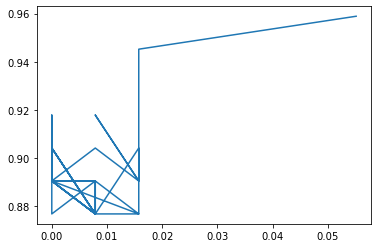

In [223]:
plt.plot(FPR, TPR)

We reproduce the plot below but with the axis range set to 0, 1 for illustrative purposes. We can see that the ROC curve is concentrated in the top right corner of the plot which suggests this range of lambda produces an accurate classifier. The FPR is very low in these cases (close to 0) and the TPR is approximately 90% or more in each case.

(0.0, 1.0)

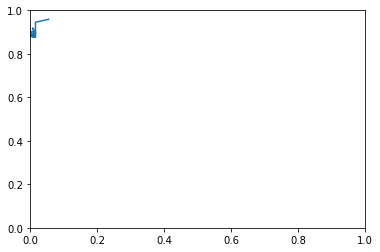

In [224]:
plt.plot(FPR, TPR)
plt.xlim(0,1)
plt.ylim(0,1)

We now repeat this process on the balanced data set.

In [215]:
# Load in the new data and prepare

data=pd.read_csv('tumour_samples_bal.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
data = np.asarray(data)

X_bal = data[:, 1:31]
y_bal = data[:, 31]
X_bal = standardise(X_bal)

# Create the balanced folds

folds_bal = np.array_split(np.arange(len(y_bal)), 5)

In [217]:
# Tune the hyperparameter

best_lam = choose_best_lam(X_bal, y_bal, folds_bal, np.arange(1,31))

CV_ACC@lambda=1: 0.934
CV_ACC@lambda=2: 0.936
CV_ACC@lambda=3: 0.941
CV_ACC@lambda=4: 0.943
CV_ACC@lambda=5: 0.945
CV_ACC@lambda=6: 0.950
CV_ACC@lambda=7: 0.950
CV_ACC@lambda=8: 0.952
CV_ACC@lambda=9: 0.951
CV_ACC@lambda=10: 0.951
CV_ACC@lambda=11: 0.954
CV_ACC@lambda=12: 0.953
CV_ACC@lambda=13: 0.953
CV_ACC@lambda=14: 0.953
CV_ACC@lambda=15: 0.953
CV_ACC@lambda=16: 0.953
CV_ACC@lambda=17: 0.954
CV_ACC@lambda=18: 0.955
CV_ACC@lambda=19: 0.958
CV_ACC@lambda=20: 0.956
CV_ACC@lambda=21: 0.958
CV_ACC@lambda=22: 0.958
CV_ACC@lambda=23: 0.956
CV_ACC@lambda=24: 0.956
CV_ACC@lambda=25: 0.956
CV_ACC@lambda=26: 0.956
CV_ACC@lambda=27: 0.956
CV_ACC@lambda=28: 0.957
CV_ACC@lambda=29: 0.956
CV_ACC@lambda=30: 0.956


In [218]:
print('best_lam:', best_lam)

best_lam: 19


In this case, we find that lambda=19 is the optimum. Having now obtained the optimal hyperparameter for the SVM on the balanced data set, we now plot an ROC curve for differing values of lambda.

In [220]:
# Run this with max iterations set to 2000

lam_range = np.linspace(1,1000,50)

TPR = []
FPR = []
acc = []

for i in lam_range:
    w = sgd(X_bal, y_bal, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=i, print_outcome=False)
    score, TP, TN, FP, FN = score_svm(w, X_test, y_test)
    acc = np.append(acc, score)
    
    if TP+FN == 0:
        TPR = np.nan
    else:
        TPR = np.append( TPR, (TP / (TP+FN)) )
    if TN+FP==0:
        TNR = np.nan
        FPR = np.nan
    else:
        TNR = TN / (TN + FP)
        FPR = np.append( FPR, (1 - TNR) )

acc

array([0.95 , 0.96 , 0.96 , 0.96 , 0.96 , 0.955, 0.95 , 0.965, 0.96 ,
       0.945, 0.945, 0.94 , 0.94 , 0.945, 0.94 , 0.945, 0.945, 0.94 ,
       0.94 , 0.945, 0.94 , 0.945, 0.94 , 0.94 , 0.945, 0.94 , 0.945,
       0.945, 0.94 , 0.945, 0.945, 0.945, 0.945, 0.95 , 0.95 , 0.945,
       0.945, 0.945, 0.955, 0.94 , 0.94 , 0.94 , 0.945, 0.94 , 0.94 ,
       0.94 , 0.94 , 0.95 , 0.95 , 0.945])

(0.0, 1.0)

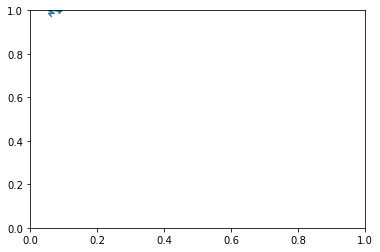

In [221]:
plt.plot(FPR, TPR)
plt.xlim(0,1)
plt.ylim(0,1)

Once again, the ROC curve is excellent. It is concentrated in the top right corner much like the previous one. We can see that the TPR is close to 100% while the FPR is approximately 10%.

<a name="task-3"></a>

# Task 3: Mastery Component [^](#outline)

<a name="q31"></a>

## 3.1 Logistic Regression and Bagging [^](#outline)

In this section we train a logistic regression model for classification. As before, we begin by loading in the data and standardising it. We implement gradient descent and then measure its accuracy.

In [225]:
data=pd.read_csv('tumour_samples.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)
data = np.asarray(data)

X = data[:, 1:31]
y = data[:, 31]
X = standardise(X)

data=pd.read_csv('tumour_test.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [0, 1], inplace=True)
data = np.asarray(data)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

We now implement gradient descent to minimise the negative log-likelihood function.

In [226]:
def logistic(x):
    return 1. / (1. + np.exp(-x))

def predict_log(X, beta, beta_0):
    y_log = logistic(X @ beta + beta_0)
    return y_log.squeeze()

def propagate(X, y, beta, beta_0):
    y_log = predict_log(X, beta, beta_0)

    # Cost function
    cost = - (y * np.log(y_log) + (1-y) * np.log(1 - y_log)).mean()

    # Derivatives
    
    dbeta = 0
    
    for i in range(len(y)):
        dbeta += X[i,:] * (y_log[i] - y[i])
    
    dbeta = (dbeta/X.shape[0]).reshape(-1,1)
    dbeta_0 =  (y_log - y).mean()

    assert(dbeta.shape==beta.shape)
    assert(dbeta_0.dtype==float)
    cost = np.squeeze(cost)
    assert(cost.shape==())
  
    # store gradients in a dictionary
    grads = {"dbeta": dbeta, "dbeta_0": dbeta_0}
  
    return grads, cost

def optimise(X, y, beta, beta_0, num_iterations=5000, learning_rate=0.005, print_cost=False):
    costs = []
    
    for i in range(num_iterations):

        # calculate cost and gradients
        grads, cost = propagate(X, y, beta, beta_0)
      
        # retrieve derivatives from grads
        dbeta = grads["dbeta"]
        dbeta_0 = grads["dbeta_0"]
      
        # updating procedure
        beta = beta - learning_rate * dbeta
        beta_0 = beta_0 - learning_rate * dbeta_0
      
        # record the costs
        if i % 100 == 0:
            costs.append(cost)
      
        # print the cost every 100 iterations
        if print_cost and i % 100 == 0:
            print ("cost after iteration %i: %f" %(i, cost))
  
    # save parameters and gradients in dictionary
    params = {"beta": beta, "beta_0": beta_0}
    grads = {"dbeta": dbeta, "dbeta_0": dbeta_0}
  
    return params, grads, costs

In [227]:
# Initialise the vector beta and the corresponding scalar

beta = np.zeros(shape = (X.shape[1],1), dtype=float)
beta_0 = 0

parameters, grads, costs = optimise(X, y, beta, beta_0)


We now predict using the model and measure its accuracy on both the training set and the test set.

In [228]:
def predict(X_test, beta, beta_0):
    n = X_test.shape[0]
  
    # compute vector y_log predicting the probabilities
    y_log = predict_log(X_test, beta, beta_0)

    # Returns the probability vector only, need to round to get classification
    return y_log

beta = parameters["beta"]
beta_0 = parameters["beta_0"]

pred_train = predict(X, beta, beta_0).round()
acc_train = np.mean(pred_train == y)

pred_test = predict(X_test, beta, beta_0).round()
acc_test = np.mean(pred_test == y_test)

acc_train, acc_test

(0.9859703819173812, 0.915)

The accuracy for the training and test sets is shown above respectively.

We now implement bagging in order to avoid overfitting our model. We begin by defining a function which implements this.

In [229]:
def bagging(X,y,B,n):
    
    # B = number of samples
    # n = size of each sample, in this case, approx half the total no. of samples

    # First create the random samples

    S = np.zeros(shape=(B,n), dtype='int')
    for i in range(B):
        S[i,:] = np.random.randint(low=0, high=(n-1), size=(n,))

    # Initialise the aggregated probability vector
    
    prob = 0
    beta = np.zeros(shape = (X.shape[1],1), dtype=float)
    beta_0 = []

    # Now create the B models

    for i in range(B):
        X_train = X[(S[i,:]),:]
        y_train = y[(S[i,:])]
    
        beta_sam = np.zeros(shape = (X.shape[1],1), dtype=float)
        beta_0_sam = 0
    
        parameters, grads, costs = optimise(X_train, y_train, beta_sam, beta_0_sam)
    
        beta_sam = parameters["beta"]
        beta_0_sam = parameters["beta_0"]
        
        beta += beta_sam
        beta_0 = np.append(beta_0, beta_0_sam)
    
        prob += predict(X_train, beta_sam, beta_0_sam)
        
    prob = (prob/B).round()
    beta = beta/B
    beta_0 = np.mean(beta_0)
    
    return prob, beta, beta_0

We now use 5-fold cross validation to find the optimum number of samples to use in bagging.

In [230]:
def score_bagging(X_train, y_train, X_val, y_val, B, n):
    pred_train, beta, beta_0 = bagging(X_train, y_train, B, n)
    pred_val = predict(X_val, beta, beta_0).round()
    acc = np.mean(pred_val == y_val)
    return acc

def folds_score_bagging(X, y, folds, B, n):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            score += score_bagging(X_train, y_train, X_val, y_val, B, n)
 
    score = score/N
    return score

def choose_best_B(X, y, folds, B_range, n):
    B_scores = np.zeros((len(B_range),))
    
    for i, B in enumerate(B_range):
        B_scores[i] = folds_score_bagging(X, y, folds, B, n)
        print(f'CV_ACC@B={B}: {B_scores[i]:.3f}')

        best_B_index = np.argmax(B_scores)
    return lam_range[best_B_index]

We now scan for the best number of samples. We set the size of each sample to be 2052. This is the size of the data set minus the largest fold.

In [251]:
choose_best_B(X,y,folds, np.array([5,10,15]), 2052)

CV_ACC@B=5: 0.986
CV_ACC@B=10: 0.984
CV_ACC@B=15: 0.984


1.0

The results above show that 5 is the optimal number of samples. We now measure the accuracy of our bagging model compared with the previous one. We set the sample size to be equal to the size of the data set.

In [258]:
score_bagging(X, y, X_test, y_test, 5, 2566)

0.285

The accuracy for this model is significantly worse than the previous. This is an unexpected result and possibly something has gone wrong here.

<a name="q32"></a>

## 3.2 Kernelised SVM Classifier [^](#outline)

In this section we use a kernelised SVM. The code is largely the same as in section 2.3.1 except the cost function is modified and the other functions modified to call these new ones. As before, we use +/-1 for SVM classification.

In [238]:
# Prepare the data and standardise it
# In this section, we instead use +/- 1 for the diagnosis for ease of use when using SVMs.

tumour_test = pd.read_csv('tumour_test.csv')
tumour_test['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)

data=pd.read_csv('tumour_samples_bal.csv')
data['DIAGNOSIS'].replace(['B', 'M'], [-1, 1], inplace=True)
data = np.asarray(data)

X_bal = data[:, 1:31]
y_bal = data[:, 31]
X_bal = standardise(X)

data = np.asarray(tumour_test)

X_test = data[:, 1:31]
y_test = data[:, 31]
X_test = standardise(X_test)

We first create a function for our radial basis function kernel.

In [240]:
def ker(x,y,sigma):
    ans = np.exp((-np.sum((x-y)**2))/sigma)
    return ans

We now modify the previous functions to account for this new kernel.

In [243]:
def compute_cost_ker(w, X, y, sigma, lam=1e5):
    
    n = X.shape[0]
    distances = np.zeros(shape=(n,))
    for i in range(len(y)):
        distances[i] = 1 - y[i] * ker(w, X[i,:], sigma)
        
    distances[distances < 0] = 0  # equivalent to max(0, distance)
    hinge = lam * distances.mean()  

    return 0.5 * ker(w, w, sigma) + hinge

def calculate_cost_gradient_ker(w, X_batch, y_batch, sigma, lam=1e5):
    
    # if only one example is passed
    
    if type(y_batch) == np.float64:
        y_batch = np.asarray([y_batch])
        X_batch = np.asarray([X_batch])  # gives multidimensional array

    n=X_batch.shape[0]
    distance = np.zeros(shape=n)
    for i in range(n):
        distance[i] = 1 - y_batch[i] * ker(w, X_batch[i,:], sigma)

    dw = np.zeros(len(w))

    for ind, d in enumerate(distance):
        if max(0, d)==0:
            di = w
        else:
            di = w - (lam * y_batch[ind] * X_batch[ind,:])
        dw += di

    return dw/n  # average

# Implement stochastic gradient descent

def sgd_ker(X, y, sigma, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=1e5, print_outcome=False):
    
    # initialise zero weights
    weights = np.zeros(X.shape[1])
    nth = 0
    
    # initialise starting cost as infinity
    
    prev_cost = np.inf
  
    # stochastic gradient descent
    
    indices = np.arange(len(y))
    for iteration in range(1, max_iterations):
        
        # shuffle to prevent repeating update cycles
        
        np.random.shuffle(indices)
        X, y = X[indices], y[indices]    
        
        for xi, yi in zip(X, y):
            ascent = calculate_cost_gradient_ker(weights, X, y, sigma, lam)
            weights = weights - (learning_rate * ascent)

            # convergence check on 2^n'th iteration
            
            if iteration==2**nth or iteration==max_iterations-1:
                
                # compute cost
                cost = compute_cost_ker(weights, X, y, sigma, lam)
                
                if print_outcome:
                    print("Iteration is: {}, Cost is: {}".format(iteration, cost))
        
                # stop criterion
                if abs(prev_cost - cost) < stop_criterion * prev_cost:
                    return weights
        
                prev_cost = cost
                nth += 1
  
    return weights

We now train the model on the balanced data set. We set lambda to the optimum found in section 2.3.3. We copy the cross validation code but modify it to call the new functions.

In [244]:
def folds_score_svm_ker(X, y, folds, sigma, lam):
    
    score=0
    N=len(folds)
    for i in range(N):
            val_indexes = folds[i]
            train_indexes = list(set(range(y.shape[0])) - set(val_indexes))
            X_train = X[train_indexes, :]
            y_train = y[train_indexes]
            X_val = X[val_indexes, :]
            y_val = y[val_indexes]
            
            # Train the SVM
            
            w = sgd_ker(X_train, y_train, sigma, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=lam, print_outcome=False)
            
            score += score_svm(w, X_val, y_val)[0]
 
    score = score/N
    return score

def choose_best_sigma(X, y, folds, sigma_range, lam):
    sigma_scores = np.zeros((len(sigma_range),))
    
    for i, sigma in enumerate(sigma_range):
        sigma_scores[i] = folds_score_svm_ker(X, y, folds, sigma, lam)
        print(f'CV_ACC@sigma={sigma}: {sigma_scores[i]:.3f}')

        best_sigma_index = np.argmax(sigma_scores)
    return sigma_range[best_sigma_index]

In [247]:
choose_best_sigma(X_bal, y_bal, folds_bal, np.arange(1,11), 19)

Iteration is: 1, Cost is: 19.501601568444308
Iteration is: 2, Cost is: 19.501541667734266
Iteration is: 1, Cost is: 19.497635801713777
Iteration is: 2, Cost is: 19.497480589942835
Iteration is: 1, Cost is: 19.495428402272097
Iteration is: 2, Cost is: 19.49543291114112
Iteration is: 1, Cost is: 19.490199828688134
Iteration is: 2, Cost is: 19.49020768890178
Iteration is: 1, Cost is: 19.490243953380364
Iteration is: 2, Cost is: 19.4900553298312
CV_ACC@sigma=1: 0.460
Iteration is: 1, Cost is: 19.535226074960107
Iteration is: 2, Cost is: 19.534686789228395
Iteration is: 1, Cost is: 19.525754733096306
Iteration is: 2, Cost is: 19.524775187528267
Iteration is: 1, Cost is: 19.490930166003274
Iteration is: 2, Cost is: 19.490848466693027
Iteration is: 1, Cost is: 19.427445970840868
Iteration is: 2, Cost is: 19.42757735535302
Iteration is: 1, Cost is: 19.433799119687304
Iteration is: 2, Cost is: 19.433411435934275
CV_ACC@sigma=2: 0.460
Iteration is: 1, Cost is: 19.623549943713833
Iteration is: 2,

1

From the above we see no improvement with varying values of sigma. We now train the model with sigma = 1 and measure its accuracy on the test set.

In [248]:
# Add optimum value of sigma

w = sgd_ker(X_bal, y_bal, 1, max_iterations=2000, stop_criterion=0.01, learning_rate=1e-5, lam=19, print_outcome=True)
score_svm(w, X_test, y_test)[0]

Iteration is: 1, Cost is: 19.4950219791547
Iteration is: 2, Cost is: 19.494977971936617


0.75

The accuracy of this model is much worse than the non-kernelised SVM. The reduction in accuracy would suggest that any patterns in the data classes are inherently linear and so the linear SVM is the more appropriate model in this case.

# Concluding Remarks

#### kNN Model

As for the kNN model, we used SMOTE to address the imbalanced dataset. Alternative methods could involve using weighted metrics that strongly favour observations closer to the input or bagging methods. Examining the effect of these methods provides an opportunity for further examination.